# 06 - Resultados para despliegue

En este cuaderno se preparan los resultados finales para el dashboard de predicción, la visualización temporal y la simulación de escenarios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", None)

import warnings
warnings.filterwarnings("ignore")

In [2]:
serie = pd.read_csv("../01_data/serie_externa_preparada.csv")
metricas = pd.read_csv("../01_data/metricas_modelos.csv")

pred_arima = pd.read_csv("../01_data/predicciones_arima.csv")
pred_prophet = pd.read_csv("../01_data/predicciones_prophet.csv")
pred_lstm = pd.read_csv("../01_data/predicciones_lstm.csv")

serie["Date"] = pd.to_datetime(serie["Date"])
pred_arima["Date"] = pd.to_datetime(pred_arima["Date"])
pred_prophet["Date"] = pd.to_datetime(pred_prophet["Date"])
pred_lstm["Date"] = pd.to_datetime(pred_lstm["Date"])

serie.head()

,Date,Sales,Promo,SchoolHoliday,StateHolidayFlag,Open,Promo2,CompetitionDistance
0,2013-01-01,97235,0.00,1,1,0.02,0.51,"5,409.74"
1,2013-01-02,6949829,0.00,1,0,1.00,0.51,"5,404.90"
2,2013-01-03,6347820,0.00,1,0,0.99,0.51,"5,404.90"
3,2013-01-04,6638954,0.00,1,0,0.99,0.51,"5,404.90"
4,2013-01-05,5951593,0.00,1,0,0.99,0.51,"5,404.90"


In [3]:
metricas

,Modelo,RMSE,MAE,MAPE (%)
0,ARIMA,"2,045,074.55","1,272,695.19",140.21
1,Prophet,"968,447.14","685,105.41",24.31
2,LSTM,"1,710,638.53","1,219,261.28",151.25


In [4]:
mejor_modelo = metricas.sort_values(["MAPE (%)", "MAE", "RMSE"]).iloc[0]

resultado_mejor_modelo = pd.DataFrame({
    "Modelo seleccionado": [mejor_modelo["Modelo"]],
    "RMSE": [mejor_modelo["RMSE"]],
    "MAE": [mejor_modelo["MAE"]],
    "MAPE (%)": [mejor_modelo["MAPE (%)"]]
})

resultado_mejor_modelo

,Modelo seleccionado,RMSE,MAE,MAPE (%)
0,Prophet,"968,447.14","685,105.41",24.31


## Visualización temporal

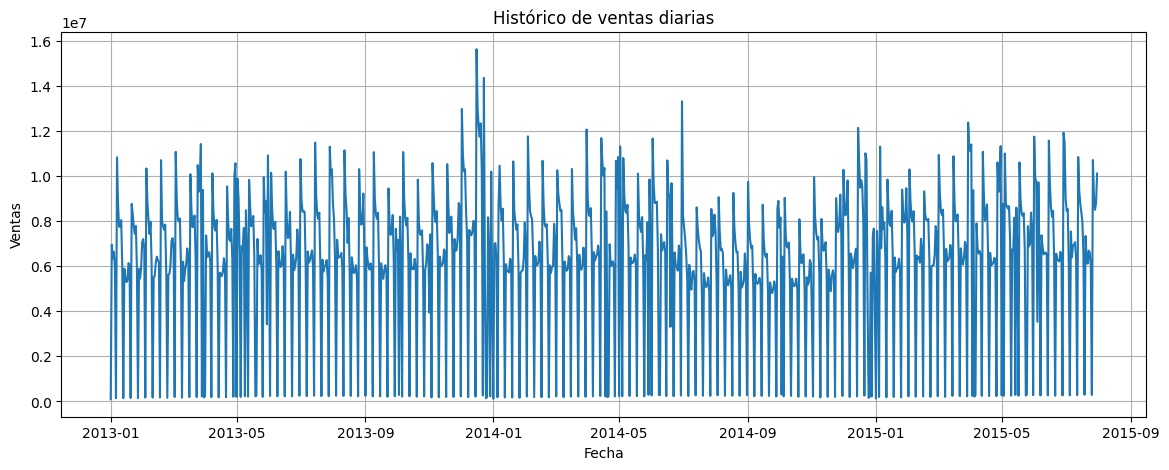

In [5]:
plt.figure(figsize=(14,5))
plt.plot(serie["Date"], serie["Sales"])
plt.title("Histórico de ventas diarias")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.grid(True)
plt.show()

## Comparación de predicciones por modelo

In [6]:
pred_prophet.head()

,Date,Real,Prediccion_Prophet
0,2015-01-24,5811369,"6,001,543.23"
1,2015-01-25,179028,"92,172.82"
2,2015-01-26,9401803,"9,413,019.26"
3,2015-01-27,8392342,"8,282,638.15"
4,2015-01-28,7930037,"7,927,264.59"


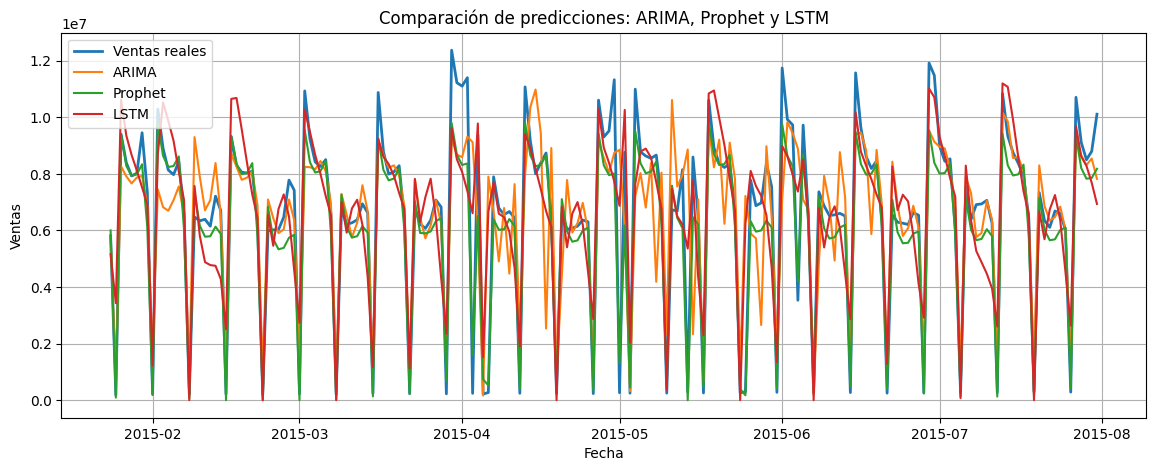

In [7]:
plt.figure(figsize=(14,5))
plt.plot(pred_arima["Date"], pred_arima["Real"], label="Ventas reales", linewidth=2)
plt.plot(pred_arima["Date"], pred_arima["Prediccion_ARIMA"], label="ARIMA")
plt.plot(pred_prophet["Date"], pred_prophet["Prediccion_Prophet"], label="Prophet")
plt.plot(pred_lstm["Date"], pred_lstm["Prediccion_LSTM"], label="LSTM")
plt.title("Comparación de predicciones: ARIMA, Prophet y LSTM")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.legend()
plt.grid(True)
plt.show()

## Simulación de escenarios

In [8]:
escenarios = pred_prophet.copy()

escenarios["Escenario_Base"] = escenarios["Prediccion_Prophet"]
escenarios["Escenario_Optimista"] = escenarios["Prediccion_Prophet"] * 1.10
escenarios["Escenario_Pesimista"] = escenarios["Prediccion_Prophet"] * 0.90

escenarios.head()


,Date,Real,Prediccion_Prophet,Escenario_Base,Escenario_Optimista,Escenario_Pesimista
0,2015-01-24,5811369,"6,001,543.23","6,001,543.23","6,601,697.56","5,401,388.91"
1,2015-01-25,179028,"92,172.82","92,172.82","101,390.10","82,955.53"
2,2015-01-26,9401803,"9,413,019.26","9,413,019.26","10,354,321.19","8,471,717.34"
3,2015-01-27,8392342,"8,282,638.15","8,282,638.15","9,110,901.97","7,454,374.34"
4,2015-01-28,7930037,"7,927,264.59","7,927,264.59","8,719,991.05","7,134,538.13"


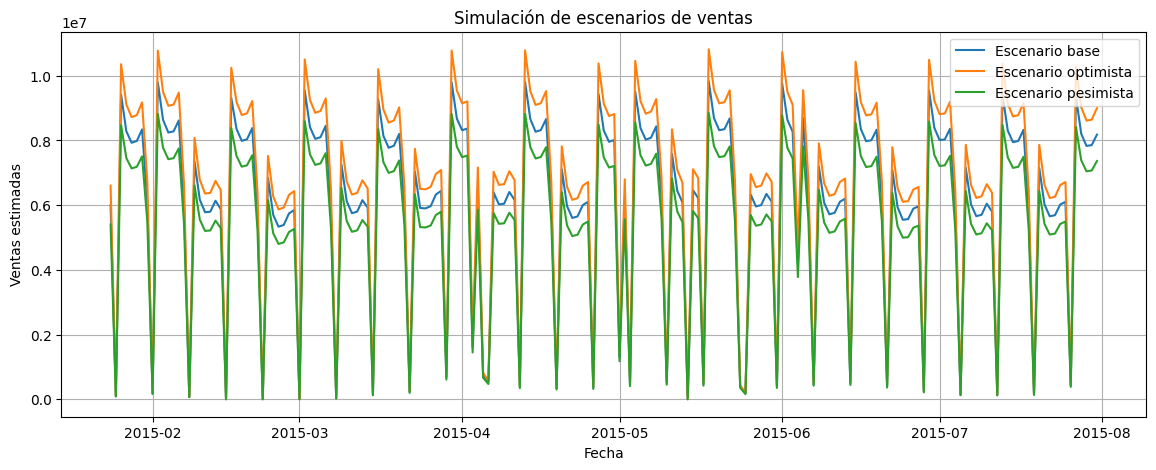

In [9]:
plt.figure(figsize=(14,5))
plt.plot(escenarios["Date"], escenarios["Escenario_Base"], label="Escenario base")
plt.plot(escenarios["Date"], escenarios["Escenario_Optimista"], label="Escenario optimista")
plt.plot(escenarios["Date"], escenarios["Escenario_Pesimista"], label="Escenario pesimista")
plt.title("Simulación de escenarios de ventas")
plt.xlabel("Fecha")
plt.ylabel("Ventas estimadas")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
resumen_escenarios = pd.DataFrame({
    "Escenario": ["Base", "Optimista", "Pesimista"],
    "Venta promedio estimada": [
        escenarios["Escenario_Base"].mean(),
        escenarios["Escenario_Optimista"].mean(),
        escenarios["Escenario_Pesimista"].mean()
    ],
    "Venta minima estimada": [
        escenarios["Escenario_Base"].min(),
        escenarios["Escenario_Optimista"].min(),
        escenarios["Escenario_Pesimista"].min()
    ],
    "Venta maxima estimada": [
        escenarios["Escenario_Base"].max(),
        escenarios["Escenario_Optimista"].max(),
        escenarios["Escenario_Pesimista"].max()
    ]
})

resumen_escenarios


,Escenario,Venta promedio estimada,Venta minima estimada,Venta maxima estimada
0,Base,"6,050,334.51",0.00,"9,834,919.56"
1,Optimista,"6,655,367.96",0.00,"10,818,411.52"
2,Pesimista,"5,445,301.06",0.00,"8,851,427.61"


## Datos para el dashboard

In [11]:
datos_dashboard = pred_prophet[["Date", "Real", "Prediccion_Prophet"]].copy()

datos_dashboard = datos_dashboard.merge(
    pred_arima[["Date", "Prediccion_ARIMA"]],
    on="Date",
    how="left"
)

datos_dashboard = datos_dashboard.merge(
    pred_lstm[["Date", "Prediccion_LSTM"]],
    on="Date",
    how="left"
)

datos_dashboard = datos_dashboard.merge(
    escenarios[[
        "Date",
        "Escenario_Base",
        "Escenario_Optimista",
        "Escenario_Pesimista"
    ]],
    on="Date",
    how="left"
)

datos_dashboard.head()

,Date,Real,Prediccion_Prophet,Prediccion_ARIMA,Prediccion_LSTM,Escenario_Base,Escenario_Optimista,Escenario_Pesimista
0,2015-01-24,5811369,"6,001,543.23","5,775,527.24","5,162,536.63","6,001,543.23","6,601,697.56","5,401,388.91"
1,2015-01-25,179028,"92,172.82","695,344.67","3,429,298.09","92,172.82","101,390.10","82,955.53"
2,2015-01-26,9401803,"9,413,019.26","8,261,890.13","10,624,170.12","9,413,019.26","10,354,321.19","8,471,717.34"
3,2015-01-27,8392342,"8,282,638.15","7,913,481.10","9,352,032.95","8,282,638.15","9,110,901.97","7,454,374.34"
4,2015-01-28,7930037,"7,927,264.59","7,662,895.67","8,672,557.04","7,927,264.59","8,719,991.05","7,134,538.13"


In [12]:
datos_dashboard.to_csv("../01_data/datos_dashboard.csv", index=False)
resumen_escenarios.to_csv("../01_data/resumen_escenarios.csv", index=False)

In [13]:
archivos_generados = pd.DataFrame({
    "Archivo": [
        "datos_dashboard.csv",
        "resumen_escenarios.csv"
    ],
    "Uso": [
        "Predicción, visualización temporal y escenarios",
        "Resumen de escenarios simulados"
    ]
})

archivos_generados

,Archivo,Uso
0,datos_dashboard.csv,"Predicción, visualización temporal y escenarios"
1,resumen_escenarios.csv,Resumen de escenarios simulados


## Conclusion

Se prepararon los resultados finales para el despliegue del proyecto. El conjunto final incluye las ventas reales, las predicciones de los modelos ARIMA, Prophet y LSTM, y los escenarios de simulacion construidos a partir del modelo Prophet.

De acuerdo con las metricas RMSE, MAE y MAPE, Prophet fue seleccionado como modelo principal, ya que obtuvo el mejor desempeno predictivo con un RMSE de 968,447.14, un MAE de 685,105.41 y un MAPE de 24.31%.

ARIMA y LSTM se mantienen en el dashboard como modelos comparativos, permitiendo visualizar el comportamiento de los tres modelos solicitados en el taller.

La simulacion de escenarios se construyo con Prophet porque fue el modelo mas adecuado para la solucion final: permite analizar estacionalidad, tendencia y variables externas, facilita la interpretacion de resultados y se integra de forma clara con el dashboard.
